### Конфигурация

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.base import clone

In [2]:
sys.path.append(os.path.abspath(os.path.join('..')))

from src.utils import log_experiment

from src.features import (
    add_target_history_features,
    add_status_history_features,
    add_status_aggregate_features,
    add_calendar_features)

from src.validation import make_cutoffs, run_backtest, prepare_backtest_frame, make_fold
from src.models import make_ridge_model
from src.metrics import metric_components, metric_by_horizon

In [3]:
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)

# Модифицируйте в соответствии со своей задачей
TRACK = "solo"  # "solo" or "team"
TRAIN_DAYS = 14
MAX_TRAIN_ROWS = 1_500_000
RIDGE_ALPHA = 4.0
RANDOM_STATE = 42

ROOT_DIR = Path(os.getcwd())
DATA_DIR = ROOT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
SUBMISSION_DIR = DATA_DIR / "submissions"

# Меняйте конфигурацию при необходимости
TRACK_CONFIG = {
    "solo": {
        "train_path": RAW_DATA_DIR / "train_solo_track.parquet",
        "test_path": RAW_DATA_DIR / "test_solo_track.parquet",
        "target_col": "target_1h",
        "forecast_points": 8,
    },
    "team": {
        "train_path": "train_team_track.parquet",
        "test_path": "test_team_track.parquet",
        "target_col": "target_2h",
        "forecast_points": 10,
    },
}

CONFIG = TRACK_CONFIG[TRACK]
TARGET_COL = CONFIG["target_col"]
FORECAST_POINTS = CONFIG["forecast_points"]
FUTURE_TARGET_COLS = [f"target_step_{step}" for step in range(1, FORECAST_POINTS + 1)]
STATUS_COLS = ["status_1", "status_2", "status_3", "status_4", "status_5", "status_6"]

### Загрузка данных

In [4]:
train_df = pd.read_parquet(CONFIG["train_path"], engine='fastparquet')
test_df = pd.read_parquet(CONFIG["test_path"], engine='fastparquet')

train_df["timestamp"] = pd.to_datetime(train_df["timestamp"])
test_df["timestamp"] = pd.to_datetime(test_df["timestamp"])

train_df = train_df.sort_values(["route_id", "timestamp"]).reset_index(drop=True)
test_df = test_df.sort_values(["route_id", "timestamp"]).reset_index(drop=True)

print("track:", TRACK)
print("train shape:", train_df.shape)
print("test shape:", test_df.shape)

track: solo
train shape: (4630000, 9)
test shape: (8000, 3)


In [5]:
print("Train date range:", train_df["timestamp"].min(), "->", train_df["timestamp"].max())
print("Test date range:", test_df["timestamp"].min(), "->", test_df["timestamp"].max())
print("Train routes:", train_df["route_id"].nunique())
print("Test routes:", test_df["route_id"].nunique())

Train date range: 2025-07-28 00:00:00 -> 2025-11-01 10:30:00
Test date range: 2025-11-01 11:00:00 -> 2025-11-01 14:30:00
Train routes: 1000
Test routes: 1000


In [6]:
train_df = train_df.sort_values(["route_id", "timestamp"]).copy()

train_df = add_status_aggregate_features(train_df)

STATUS_AGG_COLS = [
    "status_out_sum",
    "status_in_sum",
    "status_total_sum",
    "status_balance",
]

ALL_STATUS_COLS = STATUS_COLS + STATUS_AGG_COLS

train_df = add_target_history_features(
    df=train_df,
    target_col=TARGET_COL,
    group_col="route_id",
    ts_col="timestamp",
    lags=(1, 2, 4, 8, 48, 336),
    roll_windows=(4, 8, 48),
)

train_df = add_status_history_features(
    df=train_df,
    status_cols=ALL_STATUS_COLS,
    group_col="route_id",
    ts_col="timestamp",
    lags=(1, 2, 4, 8, 48),
    roll_windows=(4, 8, 48),
)

train_df = add_calendar_features(
    df=train_df,
    ts_col="timestamp",
    forecast_points=FORECAST_POINTS,
    step_minutes=30,
)

/Users/mgk/Documents/ml_learn/wb/src/features.py:64: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_roll_mean_{w}"] = (
/Users/mgk/Documents/ml_learn/wb/src/features.py:67: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_roll_std_{w}"] = (
/Users/mgk/Documents/ml_learn/wb/src/features.py:58: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To ge

In [7]:
route_group = train_df.groupby("route_id", sort=False)

for step in range(1, FORECAST_POINTS + 1):
    train_df[f"target_step_{step}"] = route_group[TARGET_COL].shift(-step)

train_df[["route_id", "timestamp", TARGET_COL] + FUTURE_TARGET_COLS].head()

,route_id,timestamp,target_1h,target_step_1,target_step_2,target_step_3,target_step_4,target_step_5,target_step_6,target_step_7,target_step_8
0,0,2025-07-28 00:00:00,87359,182291.0,271432.0,169736.0,38880.0,134137.0,134137.0,77760.0,77760.0
1,0,2025-07-28 00:30:00,182291,271432.0,169736.0,38880.0,134137.0,134137.0,77760.0,77760.0,76829.0
2,0,2025-07-28 01:00:00,271432,169736.0,38880.0,134137.0,134137.0,77760.0,77760.0,76829.0,193469.0
3,0,2025-07-28 01:30:00,169736,38880.0,134137.0,134137.0,77760.0,77760.0,76829.0,193469.0,194401.0
4,0,2025-07-28 02:00:00,38880,134137.0,134137.0,77760.0,77760.0,76829.0,193469.0,194401.0,99590.0


In [8]:
supervised_df = train_df.dropna(subset=FUTURE_TARGET_COLS).copy()
print("Rows with future targets:", supervised_df.shape)

Rows with future targets: (4622000, 228)


In [9]:
feature_cols = [
    col for col in train_df.columns
    if col not in {TARGET_COL, "timestamp", "id", *FUTURE_TARGET_COLS}
]
print("Feature columns len:", len(feature_cols))    

Feature columns len: 218


## Подбор признаков

Функция для проведения экспериментов:

In [17]:
from src.models import make_ridge_model

def feat_eng_exp(
    feature_cols,
    exp_name,
    desc_features,
    cutoffs,
    train_model_df,
    ridge_alpha=4.0,
    validation_scheme="backtest_same_weekday_n7_train14d",
    model_name="ridge",
    train_window=14,
    postprocess="none",
    notes="",
    display_scores=True,
):
    model = make_ridge_model(feature_cols, alpha=ridge_alpha)

    scores = run_backtest(
        model=model,
        train_model_df=train_model_df,
        feature_cols=feature_cols,
        future_target_cols=FUTURE_TARGET_COLS,
        cutoffs=cutoffs,
        train_days=train_window,
        step_minutes=30,
    )

    if display_scores:
        display(scores)

    mean_wape = scores["wape"].mean()
    mean_rbias = scores["rbias"].mean()
    mean_score = scores["score"].mean()

    log_experiment(
        exp_id=exp_name,
        model=model_name,
        features=desc_features,
        train_window=f"{train_window}d",
        validation_scheme=validation_scheme,
        postprocess=postprocess,
        valid_metric=mean_score,
        valid_wape=mean_wape,
        valid_rbias=mean_rbias,
        notes=notes,
    )

    return f"{exp_name}: mean_score={mean_score:.6f}, wape={mean_wape:.6f}, rbias={mean_rbias:.6f}"

In [12]:
train_model_df = prepare_backtest_frame(
    supervised_df=supervised_df,
    feature_cols=feature_cols,
    future_target_cols=FUTURE_TARGET_COLS,
)

cutoffs = make_cutoffs(
    train_model_df=train_model_df,
    future_target_cols=FUTURE_TARGET_COLS,
    reference_ts=train_df["timestamp"].max(),
    train_days=TRAIN_DAYS,
    step_minutes=30,
    n_folds=7,
    same_weekday=True,
)

### Target

#### Эксперимент 0: Бейзлайн (route_id + status_*)

In [13]:
base_features = [
    "route_id",
    "status_1", "status_2", "status_3",
    "status_4", "status_5", "status_6",
]

feat_eng_exp(
    feature_cols=base_features,
    exp_name='exp_000',
    desc_features='route_id, status_*',
    cutoffs=cutoffs,
    train_model_df=train_model_df
)

,fold,cutoff,train_rows,valid_rows,wape,rbias,score,target_step_1_wape,target_step_1_rbias,target_step_1_score,...,target_step_5_score,target_step_6_wape,target_step_6_rbias,target_step_6_score,target_step_7_wape,target_step_7_rbias,target_step_7_score,target_step_8_wape,target_step_8_rbias,target_step_8_score
0,1,2025-09-13 10:30:00,673000,1000,0.322362,0.016724,0.339085,0.299784,0.011337,0.311122,...,0.376727,0.324131,0.014833,0.338964,0.328050,0.017664,0.345714,0.328307,0.070479,0.398786
1,2,2025-09-20 10:30:00,673000,1000,0.329465,0.026869,0.356334,0.301385,0.010217,0.311602,...,0.409714,0.345550,0.000233,0.345783,0.354614,0.027656,0.382270,0.336448,0.039554,0.376002
2,3,2025-09-27 10:30:00,673000,1000,0.330399,0.033991,0.364390,0.328154,0.016066,0.344220,...,0.377295,0.327547,0.045312,0.372860,0.322951,0.078925,0.401875,0.342053,0.089049,0.431103
3,4,2025-10-04 10:30:00,673000,1000,0.338447,0.008053,0.346501,0.320961,0.008875,0.329836,...,0.349910,0.337132,0.035654,0.372786,0.339832,0.004363,0.344195,0.350185,0.001656,0.351841
4,5,2025-10-11 10:30:00,673000,1000,0.349599,0.001767,0.351366,0.326482,0.022448,0.348930,...,0.360090,0.375586,0.076253,0.451839,0.377977,0.051718,0.429696,0.358818,0.017210,0.376028
5,6,2025-10-18 10:30:00,673000,1000,0.331352,0.027010,0.358362,0.321114,0.019681,0.340795,...,0.366035,0.327401,0.011034,0.338435,0.343521,0.033657,0.377178,0.354672,0.002934,0.357606
6,7,2025-10-25 10:30:00,673000,1000,0.331592,0.034460,0.366052,0.299723,0.050923,0.350645,...,0.351689,0.320138,0.037834,0.357972,0.354434,0.019468,0.373902,0.343360,0.013742,0.357102


'exp_000: mean_score=0.354584, wape=0.333317, rbias=0.021268'

#### Эксперимент 1: base_features + target_now

In [14]:
features_target_now = base_features + [
    "target_now",
]

feat_eng_exp(
    feature_cols=features_target_now,
    exp_name='exp_001',
    desc_features='route_id, status_*, target_now',
    cutoffs=cutoffs,
    train_model_df=train_model_df
)

,fold,cutoff,train_rows,valid_rows,wape,rbias,score,target_step_1_wape,target_step_1_rbias,target_step_1_score,...,target_step_5_score,target_step_6_wape,target_step_6_rbias,target_step_6_score,target_step_7_wape,target_step_7_rbias,target_step_7_score,target_step_8_wape,target_step_8_rbias,target_step_8_score
0,1,2025-09-13 10:30:00,673000,1000,0.318534,0.017189,0.335723,0.276478,0.020481,0.296959,...,0.376747,0.324097,0.014770,0.338868,0.327960,0.018348,0.346308,0.327837,0.071409,0.399246
1,2,2025-09-20 10:30:00,673000,1000,0.326194,0.028516,0.354710,0.278244,0.005402,0.283646,...,0.409731,0.345837,0.007007,0.352844,0.354520,0.019919,0.374439,0.336850,0.039497,0.376347
2,3,2025-09-27 10:30:00,673000,1000,0.325993,0.033189,0.359182,0.297779,0.017209,0.314988,...,0.377168,0.327198,0.042852,0.370050,0.322539,0.078825,0.401364,0.341537,0.086169,0.427706
3,4,2025-10-04 10:30:00,673000,1000,0.335152,0.007374,0.342526,0.300124,0.002124,0.302248,...,0.349383,0.337026,0.035342,0.372368,0.339722,0.004853,0.344575,0.349750,0.000914,0.350664
4,5,2025-10-11 10:30:00,673000,1000,0.346763,0.000001,0.346764,0.306777,0.008563,0.315340,...,0.359731,0.375968,0.074043,0.450010,0.377621,0.050174,0.427795,0.358403,0.019662,0.378065
5,6,2025-10-18 10:30:00,673000,1000,0.327253,0.024968,0.352221,0.288151,0.001307,0.289458,...,0.365693,0.327469,0.010314,0.337782,0.343842,0.032385,0.376227,0.355907,0.004761,0.360669
6,7,2025-10-25 10:30:00,673000,1000,0.328491,0.033487,0.361977,0.282813,0.049199,0.332013,...,0.351526,0.320106,0.037768,0.357874,0.353129,0.022265,0.375393,0.343234,0.013002,0.356236


'exp_001: mean_score=0.350443, wape=0.329768, rbias=0.020675'

#### Эксперимент 2: base_features + target_now + target_lag_*

In [15]:
features_target_lags = features_target_now + [
    "target_lag_1", "target_lag_2", "target_lag_4", "target_lag_8",
    "target_lag_48", "target_lag_336",
]

feat_eng_exp(
    feature_cols=features_target_lags,
    exp_name='exp_002',
    desc_features='route_id, status_*, target_now, target_lag_*',
    cutoffs=cutoffs,
    train_model_df=train_model_df
)

,fold,cutoff,train_rows,valid_rows,wape,rbias,score,target_step_1_wape,target_step_1_rbias,target_step_1_score,...,target_step_5_score,target_step_6_wape,target_step_6_rbias,target_step_6_score,target_step_7_wape,target_step_7_rbias,target_step_7_score,target_step_8_wape,target_step_8_rbias,target_step_8_score
0,1,2025-09-13 10:30:00,673000,1000,0.316785,0.018441,0.335226,0.261122,0.011456,0.272579,...,0.381463,0.323838,0.007506,0.331344,0.327436,0.025092,0.352528,0.328039,0.076246,0.404284
1,2,2025-09-20 10:30:00,673000,1000,0.323967,0.028392,0.352359,0.260012,0.004048,0.264061,...,0.410346,0.345068,0.007587,0.352654,0.354164,0.019598,0.373762,0.337869,0.047023,0.384893
2,3,2025-09-27 10:30:00,673000,1000,0.324018,0.034527,0.358545,0.281974,0.024278,0.306252,...,0.380504,0.327576,0.047890,0.375467,0.323126,0.081473,0.404599,0.341232,0.090638,0.431870
3,4,2025-10-04 10:30:00,673000,1000,0.331839,0.008554,0.340392,0.278234,0.002840,0.281074,...,0.350670,0.337149,0.038617,0.375766,0.339402,0.001556,0.340959,0.348390,0.003807,0.352197
4,5,2025-10-11 10:30:00,673000,1000,0.343198,0.004639,0.347837,0.284898,0.009663,0.294561,...,0.362867,0.372668,0.066460,0.439128,0.375404,0.043385,0.418789,0.358118,0.025501,0.383619
5,6,2025-10-18 10:30:00,673000,1000,0.323475,0.028466,0.351941,0.258454,0.015492,0.273946,...,0.370256,0.327840,0.015568,0.343408,0.342981,0.035686,0.378667,0.354808,0.002937,0.357745
6,7,2025-10-25 10:30:00,673000,1000,0.325583,0.042214,0.367797,0.264226,0.050982,0.315209,...,0.362876,0.321064,0.050661,0.371725,0.353828,0.029089,0.382917,0.341930,0.021000,0.362930


'exp_002: mean_score=0.350585, wape=0.326981, rbias=0.023605'

#### Эксперимент 3: base_features + target_now + target_lag_* + target_roll_*

In [16]:
features_target_full = features_target_lags + [
    "target_roll_mean_4", "target_roll_std_4",
    "target_roll_mean_8", "target_roll_std_8",
    "target_roll_mean_48", "target_roll_std_48",
]

feat_eng_exp(
    feature_cols=features_target_full,
    exp_name='exp_003',
    desc_features='route_id, status_*, target_now, target_lag_*, target_roll_*',
    cutoffs=cutoffs,
    train_model_df=train_model_df
)

,fold,cutoff,train_rows,valid_rows,wape,rbias,score,target_step_1_wape,target_step_1_rbias,target_step_1_score,...,target_step_5_score,target_step_6_wape,target_step_6_rbias,target_step_6_score,target_step_7_wape,target_step_7_rbias,target_step_7_score,target_step_8_wape,target_step_8_rbias,target_step_8_score
0,1,2025-09-13 10:30:00,673000,1000,0.315620,0.020260,0.335881,0.257389,0.003677,0.261066,...,0.383713,0.320152,0.004378,0.324530,0.327310,0.027677,0.354988,0.328639,0.078871,0.407510
1,2,2025-09-20 10:30:00,673000,1000,0.321232,0.025376,0.346608,0.253274,0.015471,0.268746,...,0.406654,0.343645,0.005247,0.348892,0.352944,0.022978,0.375922,0.336893,0.043401,0.380294
2,3,2025-09-27 10:30:00,673000,1000,0.322929,0.031375,0.354304,0.270747,0.035323,0.306070,...,0.377148,0.328260,0.045476,0.373736,0.323161,0.078652,0.401812,0.340947,0.087330,0.428276
3,4,2025-10-04 10:30:00,673000,1000,0.329675,0.000797,0.330472,0.269289,0.001167,0.270456,...,0.341496,0.337335,0.028237,0.365572,0.338046,0.012463,0.350508,0.344291,0.007377,0.351667
4,5,2025-10-11 10:30:00,673000,1000,0.340616,0.013406,0.354023,0.277485,0.008608,0.286093,...,0.370815,0.372904,0.056294,0.429197,0.372045,0.033626,0.405671,0.357649,0.034566,0.392215
5,6,2025-10-18 10:30:00,673000,1000,0.321931,0.025687,0.347618,0.249955,0.011391,0.261346,...,0.367161,0.328608,0.011748,0.340357,0.342024,0.031804,0.373829,0.354527,0.007060,0.361587
6,7,2025-10-25 10:30:00,673000,1000,0.323152,0.029051,0.352204,0.253048,0.046987,0.300035,...,0.347706,0.319102,0.036178,0.355280,0.354623,0.014048,0.368671,0.340835,0.004980,0.345816


'exp_003: mean_score=0.345873, wape=0.325022, rbias=0.020851'

### Status


#### Эксперимент 4: features_target_full + status_lag_cols

In [17]:
status_lag_cols = [
    f"{col}_lag_{lag}"
    for col in STATUS_COLS
    for lag in (1, 2, 4, 8, 48)
]

features_target_plus_status_lags = features_target_full + status_lag_cols

feat_eng_exp(
    feature_cols=features_target_plus_status_lags,
    exp_name='exp_004',
    desc_features='route_id, status_*, target_now, target_lag_*, target_roll_*, status_lag_*',
    cutoffs=cutoffs,
    train_model_df=train_model_df
)

,fold,cutoff,train_rows,valid_rows,wape,rbias,score,target_step_1_wape,target_step_1_rbias,target_step_1_score,...,target_step_5_score,target_step_6_wape,target_step_6_rbias,target_step_6_score,target_step_7_wape,target_step_7_rbias,target_step_7_score,target_step_8_wape,target_step_8_rbias,target_step_8_score
0,1,2025-09-13 10:30:00,673000,1000,0.313791,0.006289,0.320080,0.251679,0.008611,0.260291,...,0.358465,0.323984,0.033104,0.357087,0.328050,0.009012,0.337062,0.327863,0.059466,0.387328
1,2,2025-09-20 10:30:00,673000,1000,0.319535,0.011553,0.331088,0.248927,0.011837,0.260765,...,0.385505,0.343710,0.015357,0.359067,0.356634,0.048835,0.405469,0.335654,0.020719,0.356373
2,3,2025-09-27 10:30:00,673000,1000,0.321516,0.017309,0.338825,0.267726,0.042818,0.310544,...,0.368870,0.328854,0.035847,0.364700,0.322092,0.056268,0.378360,0.338889,0.063729,0.402618
3,4,2025-10-04 10:30:00,673000,1000,0.330329,0.033621,0.363951,0.267116,0.016314,0.283430,...,0.356496,0.338975,0.006684,0.345659,0.344031,0.047610,0.391641,0.349576,0.047821,0.397397
4,5,2025-10-11 10:30:00,673000,1000,0.341795,0.021809,0.363604,0.274754,0.024849,0.299603,...,0.381041,0.382873,0.102778,0.485651,0.380775,0.078624,0.459399,0.360789,0.001670,0.362459
5,6,2025-10-18 10:30:00,673000,1000,0.321296,0.004291,0.325587,0.250256,0.002390,0.252646,...,0.337801,0.330946,0.020258,0.351204,0.342079,0.003368,0.345447,0.359536,0.046940,0.406476
6,7,2025-10-25 10:30:00,673000,1000,0.323095,0.015987,0.339083,0.250748,0.018950,0.269698,...,0.377809,0.319095,0.002907,0.322003,0.354752,0.022729,0.377481,0.345719,0.036243,0.381961


'exp_004: mean_score=0.340317, wape=0.324480, rbias=0.015837'

#### Эксперимент 5: features_target_full + status_lag_cols + status_roll_cols

In [18]:
status_roll_cols = [
    f"{col}_roll_mean_{w}"
    for col in STATUS_COLS
    for w in (4, 8, 48)
] + [
    f"{col}_roll_std_{w}"
    for col in STATUS_COLS
    for w in (4, 8, 48)
]

features_target_plus_status_full = features_target_full + status_lag_cols + status_roll_cols

feat_eng_exp(
    feature_cols=features_target_plus_status_full,
    exp_name='exp_005',
    desc_features='route_id, status_*, target_now, target_lag_*, target_roll_*, status_lag_*, status_roll_*',
    cutoffs=cutoffs,
    train_model_df=train_model_df
)

,fold,cutoff,train_rows,valid_rows,wape,rbias,score,target_step_1_wape,target_step_1_rbias,target_step_1_score,...,target_step_5_score,target_step_6_wape,target_step_6_rbias,target_step_6_score,target_step_7_wape,target_step_7_rbias,target_step_7_score,target_step_8_wape,target_step_8_rbias,target_step_8_score
0,1,2025-09-13 10:30:00,673000,1000,0.313553,0.008627,0.322180,0.249927,0.008997,0.258924,...,0.361337,0.323587,0.026807,0.350395,0.327903,0.011354,0.339258,0.328064,0.064568,0.392632
1,2,2025-09-20 10:30:00,673000,1000,0.317847,0.016803,0.334650,0.248879,0.013199,0.262079,...,0.391705,0.341197,0.009536,0.350732,0.354678,0.036752,0.391429,0.333930,0.028884,0.362815
2,3,2025-09-27 10:30:00,673000,1000,0.320930,0.016344,0.337274,0.266197,0.037160,0.303358,...,0.360603,0.327647,0.025602,0.353249,0.322043,0.056878,0.378921,0.338926,0.061900,0.400825
3,4,2025-10-04 10:30:00,673000,1000,0.329090,0.026489,0.355579,0.266500,0.014497,0.280997,...,0.348562,0.338507,0.001222,0.339729,0.344763,0.044432,0.389195,0.349108,0.044405,0.393513
4,5,2025-10-11 10:30:00,673000,1000,0.339892,0.019226,0.359118,0.274319,0.022004,0.296323,...,0.376773,0.384887,0.103042,0.487929,0.378289,0.062382,0.440672,0.362056,0.011462,0.373518
5,6,2025-10-18 10:30:00,673000,1000,0.321370,0.003255,0.324625,0.250421,0.004781,0.255202,...,0.345900,0.331204,0.010900,0.342104,0.342815,0.005785,0.348600,0.360395,0.039982,0.400377
6,7,2025-10-25 10:30:00,673000,1000,0.322631,0.014610,0.337241,0.250295,0.026815,0.277110,...,0.377915,0.318699,0.007625,0.326324,0.353061,0.030511,0.383572,0.345532,0.045253,0.390785


'exp_005: mean_score=0.338667, wape=0.323616, rbias=0.015051'

### Агрегаты Status, лаги агрегатов, rolling агрегатов

#### Эксперимент 6: features_target_plus_status_full + status_agg_base_cols

In [19]:
status_agg_base_cols = [
    "status_out_sum",
    "status_in_sum",
    "status_total_sum",
    "status_balance",
]

features_plus_status_aggs = features_target_plus_status_full + status_agg_base_cols

feat_eng_exp(
    feature_cols=features_plus_status_aggs,
    exp_name='exp_006',
    desc_features='route_id, status_*, target_now, target_lag_*, target_roll_*, status_lag_*, status_roll_*, status_agg_base_cols',
    cutoffs=cutoffs,
    train_model_df=train_model_df
)

,fold,cutoff,train_rows,valid_rows,wape,rbias,score,target_step_1_wape,target_step_1_rbias,target_step_1_score,...,target_step_5_score,target_step_6_wape,target_step_6_rbias,target_step_6_score,target_step_7_wape,target_step_7_rbias,target_step_7_score,target_step_8_wape,target_step_8_rbias,target_step_8_score
0,1,2025-09-13 10:30:00,673000,1000,0.313597,0.007821,0.321418,0.250249,0.004086,0.254335,...,0.361023,0.323376,0.027524,0.350900,0.328031,0.010241,0.338272,0.328031,0.063788,0.391819
1,2,2025-09-20 10:30:00,673000,1000,0.317657,0.017543,0.335201,0.248335,0.012006,0.260341,...,0.390625,0.340885,0.007911,0.348797,0.354794,0.037542,0.392336,0.333802,0.028256,0.362058
2,3,2025-09-27 10:30:00,673000,1000,0.320924,0.016439,0.337363,0.266158,0.037408,0.303566,...,0.361340,0.327741,0.024067,0.351808,0.322119,0.058198,0.380317,0.338913,0.061512,0.400425
3,4,2025-10-04 10:30:00,673000,1000,0.329095,0.026646,0.355742,0.266771,0.013728,0.280499,...,0.349017,0.338420,0.000912,0.339332,0.344694,0.043263,0.387958,0.348775,0.044450,0.393224
4,5,2025-10-11 10:30:00,673000,1000,0.340384,0.019786,0.360170,0.274598,0.021604,0.296202,...,0.379465,0.385042,0.103692,0.488733,0.381983,0.080946,0.462929,0.361423,0.006855,0.368278
5,6,2025-10-18 10:30:00,673000,1000,0.321274,0.004027,0.325302,0.250398,0.005847,0.256245,...,0.343807,0.331230,0.006663,0.337893,0.342853,0.005769,0.348622,0.360231,0.039223,0.399454
6,7,2025-10-25 10:30:00,673000,1000,0.322303,0.014484,0.336787,0.250454,0.024791,0.275245,...,0.373079,0.318669,0.007140,0.325809,0.353018,0.030616,0.383634,0.345365,0.044266,0.389631


'exp_006: mean_score=0.338854, wape=0.323605, rbias=0.015249'

#### Эксперимент 7: features_target_plus_status_full + status_agg_base_cols + status_agg_lag_cols

In [20]:
status_agg_lag_cols = [
    f"{col}_lag_{lag}"
    for col in status_agg_base_cols
    for lag in (1, 2, 4, 8, 48)
]

features_plus_status_aggs_lags = (
    features_target_plus_status_full
    + status_agg_base_cols
    + status_agg_lag_cols
)

feat_eng_exp(
    feature_cols=features_plus_status_aggs_lags,
    exp_name='exp_007',
    desc_features='route_id, status_*, target_now, target_lag_*, target_roll_*, status_lag_*, status_roll_*, status_agg_base_cols, status_agg_lag_*',
    cutoffs=cutoffs,
    train_model_df=train_model_df
)

,fold,cutoff,train_rows,valid_rows,wape,rbias,score,target_step_1_wape,target_step_1_rbias,target_step_1_score,...,target_step_5_score,target_step_6_wape,target_step_6_rbias,target_step_6_score,target_step_7_wape,target_step_7_rbias,target_step_7_score,target_step_8_wape,target_step_8_rbias,target_step_8_score
0,1,2025-09-13 10:30:00,673000,1000,0.313737,0.007283,0.321019,0.250400,0.002818,0.253218,...,0.360216,0.323938,0.027853,0.351791,0.327649,0.012309,0.339957,0.328344,0.063624,0.391969
1,2,2025-09-20 10:30:00,673000,1000,0.317601,0.017871,0.335472,0.247578,0.007433,0.255010,...,0.392375,0.340994,0.008167,0.349161,0.354810,0.038000,0.392810,0.333891,0.028474,0.362365
2,3,2025-09-27 10:30:00,673000,1000,0.320820,0.016640,0.337460,0.266447,0.039750,0.306198,...,0.360454,0.327673,0.025872,0.353544,0.321984,0.057164,0.379148,0.338894,0.063684,0.402578
3,4,2025-10-04 10:30:00,673000,1000,0.329292,0.027346,0.356638,0.267204,0.017204,0.284409,...,0.349021,0.338650,0.002013,0.340663,0.344625,0.044563,0.389188,0.349157,0.043328,0.392485
4,5,2025-10-11 10:30:00,673000,1000,0.340098,0.017663,0.357761,0.273535,0.007008,0.280543,...,0.378466,0.384823,0.102838,0.487661,0.381502,0.079116,0.460619,0.361899,0.010066,0.371965
5,6,2025-10-18 10:30:00,673000,1000,0.321347,0.004368,0.325715,0.250320,0.009129,0.259449,...,0.343819,0.331164,0.009913,0.341077,0.342850,0.006688,0.349538,0.360403,0.038560,0.398963
6,7,2025-10-25 10:30:00,673000,1000,0.322145,0.013751,0.335896,0.249542,0.026441,0.275984,...,0.376591,0.318550,0.006865,0.325416,0.352930,0.030401,0.383331,0.344290,0.041420,0.385710


'exp_007: mean_score=0.338566, wape=0.323577, rbias=0.014989'

#### Эксперимент 8: features_target_plus_status_full + status_agg_base_cols + status_agg_lag_cols + status_agg_roll_cols

In [21]:
status_agg_roll_cols = [
    f"{col}_roll_mean_{w}"
    for col in status_agg_base_cols
    for w in (4, 8, 48)
] + [
    f"{col}_roll_std_{w}"
    for col in status_agg_base_cols
    for w in (4, 8, 48)
]

features_plus_status_aggs_full = (
    features_target_plus_status_full
    + status_agg_base_cols
    + status_agg_lag_cols
    + status_agg_roll_cols
)

feat_eng_exp(
    feature_cols=features_plus_status_aggs_full,
    exp_name='exp_008',
    desc_features='route_id, status_*, target_now, target_lag_*, target_roll_*, status_lag_*, status_roll_*, status_agg_base_cols, status_agg_lag_*, status_agg_roll_*',
    cutoffs=cutoffs,
    train_model_df=train_model_df
)

,fold,cutoff,train_rows,valid_rows,wape,rbias,score,target_step_1_wape,target_step_1_rbias,target_step_1_score,...,target_step_5_score,target_step_6_wape,target_step_6_rbias,target_step_6_score,target_step_7_wape,target_step_7_rbias,target_step_7_score,target_step_8_wape,target_step_8_rbias,target_step_8_score
0,1,2025-09-13 10:30:00,673000,1000,0.313279,0.010653,0.323932,0.250105,0.006266,0.256371,...,0.364674,0.322830,0.021453,0.344283,0.327998,0.012538,0.340536,0.327147,0.057382,0.384529
1,2,2025-09-20 10:30:00,673000,1000,0.317554,0.020241,0.337795,0.248533,0.009073,0.257606,...,0.394656,0.340727,0.006057,0.346784,0.354557,0.037459,0.392015,0.334143,0.026425,0.360568
2,3,2025-09-27 10:30:00,673000,1000,0.320827,0.016740,0.337567,0.265513,0.038331,0.303844,...,0.361226,0.327793,0.026971,0.354764,0.322101,0.056326,0.378427,0.338986,0.063843,0.402829
3,4,2025-10-04 10:30:00,673000,1000,0.329758,0.031014,0.360772,0.267318,0.019975,0.287293,...,0.355420,0.338927,0.002895,0.341822,0.345602,0.049212,0.394814,0.350328,0.050819,0.401148
4,5,2025-10-11 10:30:00,673000,1000,0.340092,0.015874,0.355966,0.273526,0.008306,0.281832,...,0.381125,0.385250,0.103983,0.489233,0.380241,0.073782,0.454023,0.362421,0.001670,0.364091
5,6,2025-10-18 10:30:00,673000,1000,0.321318,0.006650,0.327967,0.250255,0.010752,0.261007,...,0.346423,0.331070,0.008759,0.339829,0.342739,0.006742,0.349481,0.360588,0.039981,0.400570
6,7,2025-10-25 10:30:00,673000,1000,0.322131,0.010302,0.332432,0.249680,0.026355,0.276035,...,0.373344,0.318501,0.000038,0.318540,0.352245,0.025723,0.377968,0.345809,0.045597,0.391406


'exp_008: mean_score=0.339490, wape=0.323565, rbias=0.015925'

#### Эксперимент 9: features_target_plus_status_full + status_agg_base_cols + status_agg_lag_cols + status_agg_roll_cols + status_agg_ratio_cols

In [22]:
status_agg_ratio_cols = [
    "status_out_share",
    "status_in_share",
    "status_out_in_ratio",
]

features_plus_status_aggs_ratios = features_plus_status_aggs_full + status_agg_ratio_cols

feat_eng_exp(
    feature_cols=features_plus_status_aggs_ratios,
    exp_name='exp_009',
    desc_features='route_id, status_*, target_now, target_lag_*, target_roll_*, status_lag_*, status_roll_*, status_agg_base_cols, status_agg_lag_*, status_agg_roll_*, status_agg_ratio',
    cutoffs=cutoffs,
    train_model_df=train_model_df
)

,fold,cutoff,train_rows,valid_rows,wape,rbias,score,target_step_1_wape,target_step_1_rbias,target_step_1_score,...,target_step_5_score,target_step_6_wape,target_step_6_rbias,target_step_6_score,target_step_7_wape,target_step_7_rbias,target_step_7_score,target_step_8_wape,target_step_8_rbias,target_step_8_score
0,1,2025-09-13 10:30:00,673000,1000,0.313237,0.010261,0.323499,0.250182,0.005539,0.255721,...,0.365513,0.322927,0.022576,0.345503,0.327671,0.011298,0.338969,0.327556,0.058290,0.385845
1,2,2025-09-20 10:30:00,673000,1000,0.317457,0.020871,0.338328,0.248125,0.007344,0.255469,...,0.395403,0.340480,0.001391,0.341871,0.354490,0.036518,0.391008,0.334097,0.024381,0.358478
2,3,2025-09-27 10:30:00,673000,1000,0.321130,0.017096,0.338225,0.266443,0.040213,0.306656,...,0.361327,0.328319,0.027385,0.355704,0.322232,0.058157,0.380390,0.338918,0.064041,0.402959
3,4,2025-10-04 10:30:00,673000,1000,0.329819,0.030927,0.360746,0.267275,0.016996,0.284271,...,0.353968,0.338926,0.002943,0.341869,0.345636,0.049088,0.394723,0.350384,0.050760,0.401144
4,5,2025-10-11 10:30:00,673000,1000,0.340244,0.014584,0.354828,0.273479,0.008122,0.281601,...,0.360854,0.385008,0.101837,0.486845,0.382064,0.079840,0.461904,0.362564,0.009401,0.371965
5,6,2025-10-18 10:30:00,673000,1000,0.321059,0.007222,0.328281,0.250123,0.012276,0.262399,...,0.346570,0.330852,0.007662,0.338514,0.342070,0.012152,0.354222,0.359804,0.034454,0.394258
6,7,2025-10-25 10:30:00,673000,1000,0.322067,0.010348,0.332415,0.249847,0.026704,0.276552,...,0.371366,0.318424,0.000263,0.318687,0.352209,0.025432,0.377641,0.345929,0.046420,0.392348


'exp_009: mean_score=0.339475, wape=0.323573, rbias=0.015901'

### Calendar

#### Эксперимент 10: features_plus_status_aggs_full + source_calendar_cols

In [23]:
source_calendar_cols = [
    "source_hour",
    "source_minute",
    "source_halfhour_slot",
    "source_dayofweek",
    "source_is_weekend",
    "source_hour_sin",
    "source_hour_cos",
    "source_dow_sin",
    "source_dow_cos",
]

features_plus_calendar_source = features_plus_status_aggs_full + source_calendar_cols # если ratios лучше поменять и в desc_features добавить

feat_eng_exp(
    feature_cols=features_plus_calendar_source,
    exp_name='exp_010',
    desc_features='route_id, status_*, target_now, target_lag_*, target_roll_*, status_lag_*, status_roll_*, status_agg_base_cols, status_agg_lag_*, status_agg_roll_*, source_calendar_cols',
    cutoffs=cutoffs,
    train_model_df=train_model_df
)

,fold,cutoff,train_rows,valid_rows,wape,rbias,score,target_step_1_wape,target_step_1_rbias,target_step_1_score,...,target_step_5_score,target_step_6_wape,target_step_6_rbias,target_step_6_score,target_step_7_wape,target_step_7_rbias,target_step_7_score,target_step_8_wape,target_step_8_rbias,target_step_8_score
0,1,2025-09-13 10:30:00,673000,1000,0.313156,0.012010,0.325166,0.249879,0.014463,0.264341,...,0.363480,0.322458,0.023247,0.345705,0.327439,0.012222,0.339661,0.327421,0.056981,0.384402
1,2,2025-09-20 10:30:00,673000,1000,0.317735,0.010741,0.328476,0.248093,0.005126,0.253219,...,0.383131,0.342739,0.018386,0.361125,0.356416,0.050658,0.407074,0.334020,0.009610,0.343629
2,3,2025-09-27 10:30:00,673000,1000,0.321055,0.006760,0.327815,0.265267,0.039269,0.304536,...,0.350290,0.327617,0.013602,0.341220,0.321761,0.044156,0.365917,0.339013,0.050035,0.389048
3,4,2025-10-04 10:30:00,673000,1000,0.330531,0.036857,0.367388,0.267705,0.019591,0.287296,...,0.365572,0.338886,0.010646,0.349532,0.345418,0.055284,0.400702,0.350905,0.057255,0.408160
4,5,2025-10-11 10:30:00,673000,1000,0.341108,0.031623,0.372731,0.275003,0.021332,0.296335,...,0.384254,0.386916,0.115182,0.502098,0.382877,0.091472,0.474349,0.362688,0.021636,0.384324
5,6,2025-10-18 10:30:00,673000,1000,0.321129,0.008122,0.329251,0.250330,0.015274,0.265605,...,0.348146,0.330392,0.004351,0.334743,0.343262,0.012319,0.355582,0.359411,0.034003,0.393413
6,7,2025-10-25 10:30:00,673000,1000,0.322532,0.011626,0.334158,0.249637,0.029981,0.279619,...,0.373002,0.318668,0.000177,0.318845,0.352282,0.024542,0.376824,0.345544,0.044106,0.389651


'exp_010: mean_score=0.340712, wape=0.323892, rbias=0.016820'

#### Эксперимент 11: features_plus_status_aggs_full + source_calendar_cols + future_calendar_cols

In [24]:
future_calendar_cols = []

for h in range(1, FORECAST_POINTS + 1):
    future_calendar_cols += [
        f"future_hour_step_{h}",
        f"future_minute_step_{h}",
        f"future_halfhour_slot_step_{h}",
        f"future_dayofweek_step_{h}",
        f"future_is_weekend_step_{h}",
        f"future_hour_sin_step_{h}",
        f"future_hour_cos_step_{h}",
        f"future_dow_sin_step_{h}",
        f"future_dow_cos_step_{h}",
    ]
    
features_plus_calendar_full = features_plus_status_aggs_full + source_calendar_cols + future_calendar_cols

feat_eng_exp(
    feature_cols=features_plus_calendar_full,
    exp_name='exp_011',
    desc_features='route_id, status_*, target_now, target_lag_*, target_roll_*, status_lag_*, status_roll_*, status_agg_base_cols, status_agg_lag_*, status_agg_roll_*, source_calendar_cols, future_calendar_cols',
    cutoffs=cutoffs,
    train_model_df=train_model_df
)

,fold,cutoff,train_rows,valid_rows,wape,rbias,score,target_step_1_wape,target_step_1_rbias,target_step_1_score,...,target_step_5_score,target_step_6_wape,target_step_6_rbias,target_step_6_score,target_step_7_wape,target_step_7_rbias,target_step_7_score,target_step_8_wape,target_step_8_rbias,target_step_8_score
0,1,2025-09-13 10:30:00,673000,1000,0.312569,0.014773,0.327342,0.249043,0.022433,0.271476,...,0.364880,0.322851,0.027827,0.350678,0.327320,0.004735,0.332055,0.326510,0.052243,0.378753
1,2,2025-09-20 10:30:00,673000,1000,0.317896,0.009824,0.327721,0.247662,0.001293,0.248956,...,0.379238,0.343840,0.025472,0.369312,0.358229,0.059562,0.417791,0.334905,0.002832,0.337737
2,3,2025-09-27 10:30:00,673000,1000,0.320910,0.005627,0.326537,0.264552,0.035417,0.299969,...,0.343374,0.327763,0.009434,0.337196,0.322383,0.038877,0.361261,0.339188,0.043150,0.382338
3,4,2025-10-04 10:30:00,673000,1000,0.330684,0.036788,0.367472,0.267327,0.015195,0.282522,...,0.367055,0.339028,0.010785,0.349813,0.346071,0.057822,0.403893,0.351883,0.060881,0.412764
4,5,2025-10-11 10:30:00,673000,1000,0.341423,0.034253,0.375676,0.275145,0.024923,0.300069,...,0.397784,0.387696,0.118560,0.506257,0.383271,0.094320,0.477591,0.362865,0.023205,0.386070
5,6,2025-10-18 10:30:00,673000,1000,0.321126,0.005859,0.326985,0.249888,0.014088,0.263976,...,0.341320,0.331327,0.010059,0.341386,0.344172,0.007891,0.352062,0.359618,0.036370,0.395988
6,7,2025-10-25 10:30:00,673000,1000,0.322398,0.011112,0.333510,0.249571,0.031973,0.281545,...,0.371722,0.319051,0.001850,0.320901,0.352108,0.025234,0.377342,0.345404,0.044207,0.389611


'exp_011: mean_score=0.340749, wape=0.323858, rbias=0.016891'

,exp_id,features,valid_metric,valid_wape,valid_rbias
0,exp_000,"route_id, status_*",0.354584,0.333317,0.021268
1,exp_001,"route_id, status_*, target_now",0.350443,0.329768,0.020675
2,exp_002,"route_id, status_*, target_now, target_lag_*",0.350585,0.326981,0.023605
3,exp_003,"route_id, status_*, target_now, target_lag_*, ...",0.345873,0.325022,0.020851
4,exp_004,"route_id, status_*, target_now, target_lag_*, ...",0.340317,0.324480,0.015837
5,exp_005,"route_id, status_*, target_now, target_lag_*, ...",0.338667,0.323616,0.015051
6,exp_006,"route_id, status_*, target_now, target_lag_*, ...",0.338854,0.323605,0.015249
7,exp_007,"route_id, status_*, target_now, target_lag_*, ...",0.338566,0.323577,0.014989
8,exp_008,"route_id, status_*, target_now, target_lag_*, ...",0.339490,0.323565,0.015925
9,exp_009,"route_id, status_*, target_now, target_lag_*, ...",0.339475,0.323573,0.015901


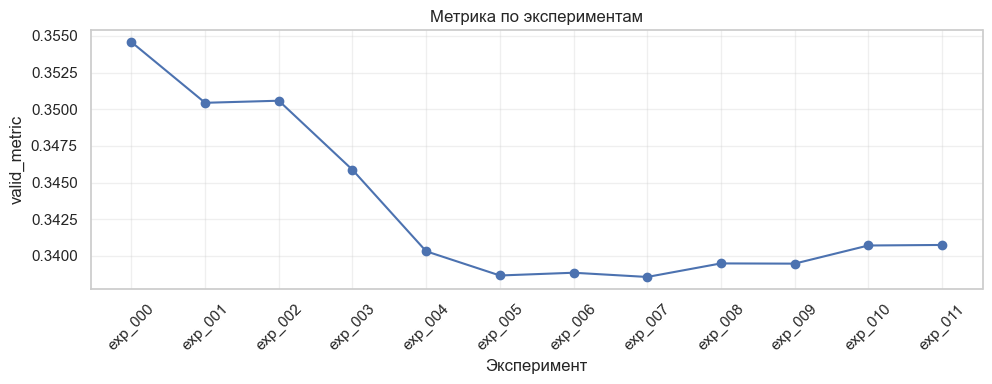

In [28]:
log_df = pd.read_csv(ROOT_DIR / "experiments/experiment_log.csv")

summary_df = log_df[["exp_id", "features", "valid_metric", "valid_wape", "valid_rbias"]].copy()

display(summary_df)

plt.figure(figsize=(10, 4))
plt.plot(summary_df["exp_id"], summary_df["valid_metric"], marker="o")
plt.title("Метрика по экспериментам")
plt.xlabel("Эксперимент")
plt.ylabel("valid_metric")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

По сводке экспериментов картина такая:

- exp_000 base (route_id + status_*) = 0.354584
- exp_001 + target_now = 0.350443
- exp_002 + target_lag_* = 0.350585
- exp_003 + target_roll_* = 0.345873
- exp_004 + status_lag_* = 0.340317
- exp_005 + status_roll_* = 0.338667
- exp_006/007/008/009 почти не дают улучшений
- exp_010/011 с календарями ухудшают итог

**Выводы:**

- target_now полезен. Он дал заметное улучшение.

- target_lag_* сами по себе не дали устойчивого улучшения итоговой метрики: локально они улучшают WAPE, но этот эффект частично компенсируется ухудшением bias.

- target_roll_* — полезны. Есть реальный прирост.

- Наибольший прирост среди последовательно добавляемых новых блоков дали status_lag_*.

- status_roll_* дали дополнительное, но уже более умеренное улучшение после status_lag_*.

- дальнейшие блоки (status_agg_*, ratio, calendar) не показали убедимого прироста в рамках текущей Ridge-CV, поэтому на текущем этапе их можно считать низкоприоритетными.


**Итоговый набор признаков для текущего основного пайплайна:**
- route_id
- status_1..status_6
- target_now
- target_lag_*
- target_roll_*
- status_lag_*
- status_roll_*

Этот набор выбран как основной, поскольку в текущей Ridge-валидации он даёт наилучшее соотношение качества, стабильности и вычислительной стоимости.

In [10]:
base_features = [
    "route_id",
    "status_1", "status_2", "status_3",
    "status_4", "status_5", "status_6",
]

features_target_lags = [
    "target_lag_1", "target_lag_2", "target_lag_4", "target_lag_8",
    "target_lag_48", "target_lag_336",
]

features_target_rolls = [
    "target_roll_mean_4", "target_roll_std_4",
    "target_roll_mean_8", "target_roll_std_8",
    "target_roll_mean_48", "target_roll_std_48",
]

status_lag_cols = [
    f"{col}_lag_{lag}"
    for col in STATUS_COLS
    for lag in (1, 2, 4, 8, 48)
]

status_roll_cols = [
    f"{col}_roll_mean_{w}"
    for col in STATUS_COLS
    for w in (4, 8, 48)
] + [
    f"{col}_roll_std_{w}"
    for col in STATUS_COLS
    for w in (4, 8, 48)
]

SELECTED_FEATURES = (base_features + 
                     ["target_now"] + 
                     features_target_lags + 
                     features_target_rolls + 
                     status_lag_cols + 
                     status_roll_cols)

## Подбор гиперпараметров

### Подбор alpha

In [ ]:
train_model_df = prepare_backtest_frame(
    supervised_df=supervised_df,
    feature_cols=SELECTED_FEATURES,
    future_target_cols=FUTURE_TARGET_COLS,
)

cutoffs = make_cutoffs(
    train_model_df=train_model_df,
    future_target_cols=FUTURE_TARGET_COLS,
    reference_ts=train_df["timestamp"].max(),
    train_days=TRAIN_DAYS,
    step_minutes=30,
    n_folds=5,
    same_weekday=True,
)

In [15]:
alphas = [0.5, 1.0, 2.0, 4.0, 8.0, 16.0]

for num_exp, alpha in enumerate(alphas):
    feat_eng_exp(
        feature_cols=SELECTED_FEATURES,
        ridge_alpha=alpha,
        exp_name=f"exp_{num_exp+12:03d}",
        desc_features='route_id, status_*, target_now, target_lag_*, target_roll_*, status_lag_*, status_roll_*',
        validation_scheme="backtest_same_weekday_n5_train14d",
        cutoffs=cutoffs,
        train_model_df=train_model_df,
        notes=f'Ridge alpha = {alpha}',
        display_scores=False
    )

,exp_id,notes,valid_metric,valid_wape,valid_rbias
12,exp_0012,Ridge alpha = 0.5,0.342681,0.326967,0.015713
15,exp_0012,Ridge alpha = 4.0,0.342767,0.326783,0.015985
13,exp_0013,Ridge alpha = 1.0,0.342443,0.326825,0.015618
16,exp_0013,Ridge alpha = 8.0,0.342285,0.326692,0.015593
14,exp_0014,Ridge alpha = 2.0,0.343072,0.326925,0.016147
17,exp_0014,Ridge alpha = 16.0,0.343097,0.326591,0.016505


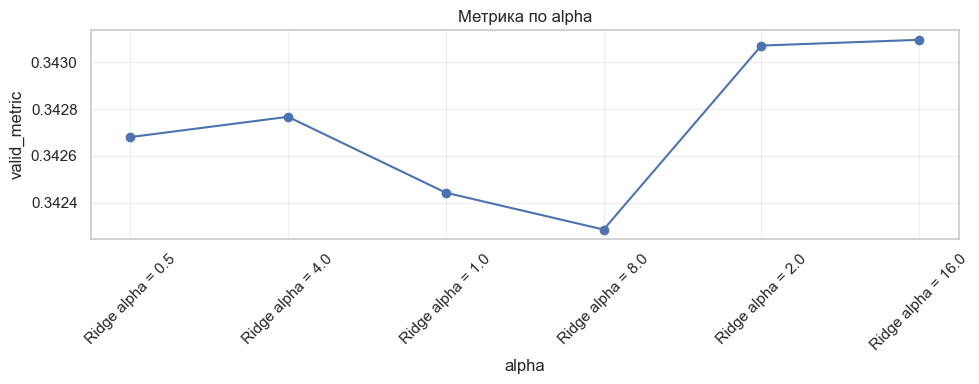

In [16]:
log_df = pd.read_csv(ROOT_DIR / "experiments/experiment_log.csv")
log_df["exp_num"] = log_df["exp_id"].str.extract(r"(\d+)").astype(int)

alpha_df = log_df[log_df["exp_num"].between(12, 17)].copy()
alpha_df = alpha_df.sort_values("exp_num")

summary_df = alpha_df[["exp_id", "notes", "valid_metric", "valid_wape", "valid_rbias"]].copy()
display(summary_df)

plt.figure(figsize=(10, 4))
plt.plot(summary_df["notes"], summary_df["valid_metric"], marker="o")
plt.title("Метрика по alpha")
plt.xlabel("alpha")
plt.ylabel("valid_metric")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
best_alpha = 8.0

### Подбор train_window

Для чистоты эксперимента, сначала строим cutoffs под самое большое окно, то есть 28d. Потом эти же cutoffs используем для 7d, 14d, 21d, 28d.
Тогда все окна сравниваются на одних и тех же датах.

In [19]:
train_windows = [7, 14, 21, 28]

cutoffs = make_cutoffs(
    train_model_df=train_model_df,
    future_target_cols=FUTURE_TARGET_COLS,
    reference_ts=train_df["timestamp"].max(),
    train_days=max(train_windows),
    step_minutes=30,
    n_folds=5,
    same_weekday=True,
)

for num_exp, train_window in enumerate(train_windows):
    feat_eng_exp(
        feature_cols=SELECTED_FEATURES,
        ridge_alpha=best_alpha,
        exp_name=f"exp_{num_exp+18:03d}",
        desc_features='route_id, status_*, target_now, target_lag_*, target_roll_*, status_lag_*, status_roll_*',
        validation_scheme=f"backtest_same_weekday_n5_train{train_window}d",
        cutoffs=cutoffs,
        train_window=train_window,
        train_model_df=train_model_df,
        notes=f'change train window={train_window}',
        display_scores=False
    )

,exp_id,train_window,valid_metric,valid_wape,valid_rbias
18,exp_018,7,0.338019,0.326461,0.011557
19,exp_019,14,0.342285,0.326692,0.015593
20,exp_020,21,0.347829,0.327056,0.020772
21,exp_021,28,0.347991,0.327055,0.020935


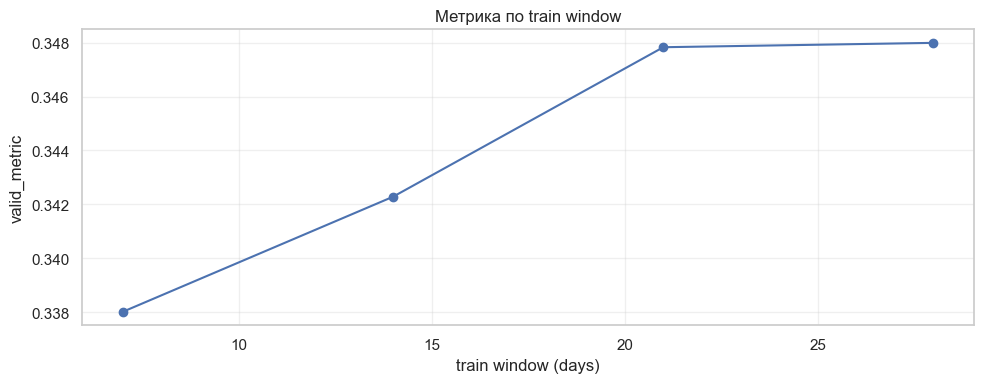

In [23]:
log_df = pd.read_csv(ROOT_DIR / "experiments/experiment_log.csv")
log_df["exp_num"] = log_df["exp_id"].str.extract(r"(\d+)").astype(int)

window_df = log_df[log_df["exp_num"].between(18, 21)].copy()
window_df = window_df.sort_values("exp_num")
window_df["train_window"] = window_df["notes"].str.extract(r"(\d+)").astype(int)

summary_df = window_df[["exp_id", "train_window", "valid_metric", "valid_wape", "valid_rbias"]].copy()
display(summary_df)

plt.figure(figsize=(10, 4))
plt.plot(summary_df["train_window"], summary_df["valid_metric"], marker="o")
plt.title("Метрика по train window")
plt.xlabel("train window (days)")
plt.ylabel("valid_metric")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

На текущем этапе наилучшее качество показало окно обучения train_window = 7. Дополнительно проверим более короткие окна 3 и 5 дней, чтобы убедиться, не лежит ли оптимум левее.

In [22]:
train_windows = [3, 5]

for num_exp, train_window in enumerate(train_windows):
    feat_eng_exp(
        feature_cols=SELECTED_FEATURES,
        ridge_alpha=best_alpha,
        exp_name=f"exp_{num_exp+22:03d}",
        desc_features='route_id, status_*, target_now, target_lag_*, target_roll_*, status_lag_*, status_roll_*',
        validation_scheme=f"backtest_same_weekday_n5_train{train_window}d",
        cutoffs=cutoffs,
        train_window=train_window,
        train_model_df=train_model_df,
        notes=f'change train window={train_window}',
        display_scores=False
    )

,exp_id,train_window,valid_metric,valid_wape,valid_rbias
22,exp_022,3,0.333811,0.326998,0.006813
23,exp_023,5,0.332520,0.326555,0.005964
18,exp_018,7,0.338019,0.326461,0.011557
19,exp_019,14,0.342285,0.326692,0.015593
20,exp_020,21,0.347829,0.327056,0.020772
21,exp_021,28,0.347991,0.327055,0.020935


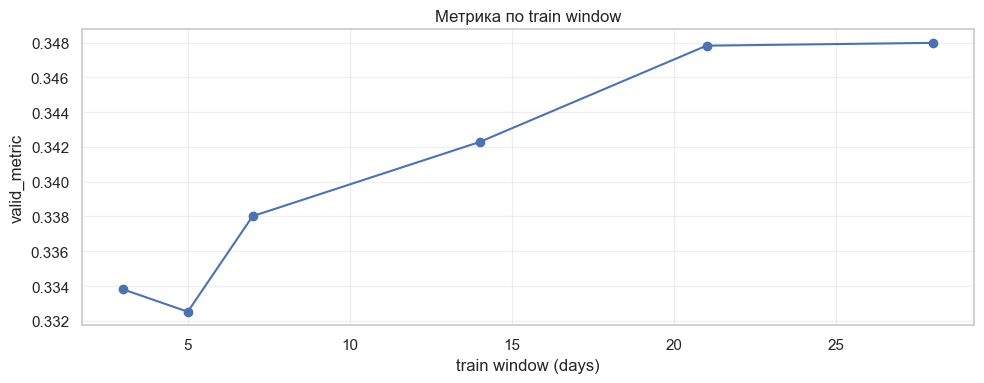

In [27]:
log_df = pd.read_csv(ROOT_DIR / "experiments/experiment_log.csv")
log_df["exp_num"] = log_df["exp_id"].str.extract(r"(\d+)").astype(int)

window_df = log_df[log_df["notes"].str.contains("train window", case=False, na=False)].copy()
window_df["train_window"] = window_df["notes"].str.extract(r"(\d+)").astype(int)
window_df = window_df.sort_values("train_window")

summary_df = window_df[["exp_id", "train_window", "valid_metric", "valid_wape", "valid_rbias"]].copy()
display(summary_df)

plt.figure(figsize=(10, 4))
plt.plot(summary_df["train_window"], summary_df["valid_metric"], marker="o")
plt.title("Метрика по train window")
plt.xlabel("train window (days)")
plt.ylabel("valid_metric")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
best_train_window = 5

Лучший результат получен при train_window = 5. Теперь повторно подберём alpha на этом окне, так как оптимальная сила регуляризации может меняться при изменении длины обучающей истории.

### Подбор alpha при train_window = 5

In [30]:
alphas = [0.5, 1.0, 2.0, 4.0, 8.0, 16.0]

for num_exp, alpha in enumerate(alphas):
    feat_eng_exp(
        feature_cols=SELECTED_FEATURES,
        ridge_alpha=alpha,
        exp_name=f"exp_{num_exp+28:03d}",
        desc_features='route_id, status_*, target_now, target_lag_*, target_roll_*, status_lag_*, status_roll_*',
        validation_scheme=f"backtest_same_weekday_n5_train{best_train_window}d",
        cutoffs=cutoffs,
        train_model_df=train_model_df,
        train_window=best_train_window,
        notes=f'Ridge alpha = {alpha}, train_window = {best_train_window}',
        display_scores=False
    )

,exp_id,notes,valid_metric,valid_wape,valid_rbias
24,exp_024,"Ridge alpha = 0.5, train_window = 5",0.333896,0.326684,0.007212
25,exp_025,"Ridge alpha = 1.0, train_window = 5",0.333876,0.326698,0.007178
26,exp_026,"Ridge alpha = 2.0, train_window = 5",0.332557,0.326489,0.006068
27,exp_027,"Ridge alpha = 4.0, train_window = 5",0.332463,0.326471,0.005992
28,exp_028,"Ridge alpha = 8.0, train_window = 5",0.332520,0.326555,0.005964
29,exp_029,"Ridge alpha = 16.0, train_window = 5",0.333135,0.326681,0.006455


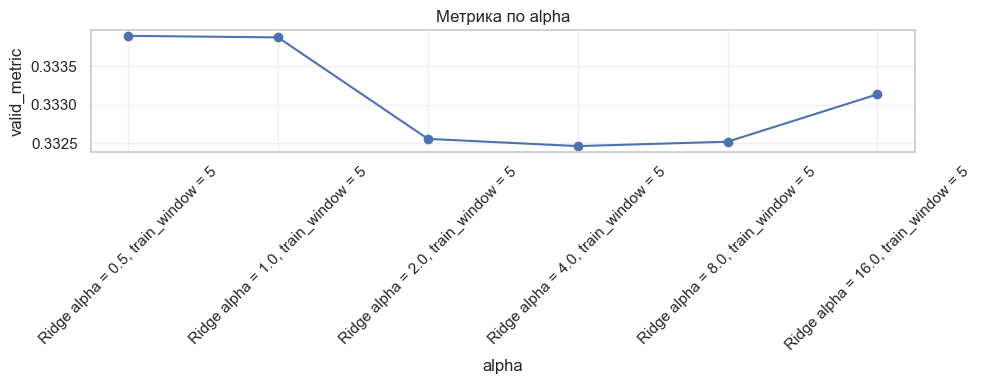

In [35]:
log_df = pd.read_csv(ROOT_DIR / "experiments/experiment_log.csv")
log_df["exp_num"] = log_df["exp_id"].str.extract(r"(\d+)").astype(int)

alpha_df = log_df[log_df["exp_num"].between(24, 29)].copy()
alpha_df = alpha_df.sort_values("exp_num")

summary_df = alpha_df[["exp_id", "notes", "valid_metric", "valid_wape", "valid_rbias"]].copy()
display(summary_df)

plt.figure(figsize=(10, 4))
plt.plot(summary_df["notes"], summary_df["valid_metric"], marker="o")
plt.title("Метрика по alpha")
plt.xlabel("alpha")
plt.ylabel("valid_metric")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

По результатам подбора гиперпараметров, лучшие значения:
- Ridge Aplha = 4.0
- Train window = 5

## Калибровка

In [11]:
FINAL_FEATURES = SELECTED_FEATURES

FINAL_TRAIN_WINDOW = 5
FINAL_ALPHA = 4.0

CALIB_N_FOLDS = 10

print("FINAL_TRAIN_WINDOW =", FINAL_TRAIN_WINDOW)
print("FINAL_ALPHA =", FINAL_ALPHA)
print("N features =", len(FINAL_FEATURES))

FINAL_TRAIN_WINDOW = 5
FINAL_ALPHA = 4.0
N features = 86


### Подготовка backtest-frame и cutoff'ов

In [51]:
train_model_df = prepare_backtest_frame(
    supervised_df=supervised_df,
    feature_cols=FINAL_FEATURES,
    future_target_cols=FUTURE_TARGET_COLS,
)

calib_cutoffs = make_cutoffs(
    train_model_df=train_model_df,
    future_target_cols=FUTURE_TARGET_COLS,
    reference_ts=train_df["timestamp"].max(),
    train_days=FINAL_TRAIN_WINDOW,
    step_minutes=30,
    n_folds=CALIB_N_FOLDS,
    same_weekday=True,
)

print("Shape train_model_df:", train_model_df.shape)
print("Calibration cutoffs:")
for ts in calib_cutoffs:
    print(" -", ts)

Shape train_model_df: (4622000, 95)
Calibration cutoffs:
 - 2025-08-23 10:30:00
 - 2025-08-30 10:30:00
 - 2025-09-06 10:30:00
 - 2025-09-13 10:30:00
 - 2025-09-20 10:30:00
 - 2025-09-27 10:30:00
 - 2025-10-04 10:30:00
 - 2025-10-11 10:30:00
 - 2025-10-18 10:30:00
 - 2025-10-25 10:30:00


### OOF-предсказания финальной модели

In [52]:
oof_true_list = []
oof_pred_list = []
fold_rows = []

for fold_id, cutoff in enumerate(calib_cutoffs, start=1):
    X_fit, y_fit, X_valid, y_valid, fit_df, valid_df = make_fold(
        train_model_df=train_model_df,
        feature_cols=FINAL_FEATURES,
        future_target_cols=FUTURE_TARGET_COLS,
        cutoff=cutoff,
        train_days=FINAL_TRAIN_WINDOW,
        step_minutes=30,
    )

    fold_model = make_ridge_model(FINAL_FEATURES, alpha=FINAL_ALPHA)
    fold_model.fit(X_fit, y_fit)

    pred_valid = np.asarray(fold_model.predict(X_valid), dtype=float)
    pred_valid = np.clip(pred_valid, 0.0, None)   # обязательный clip negatives

    y_valid_np = y_valid.to_numpy(dtype=float)

    oof_true_list.append(y_valid_np)
    oof_pred_list.append(pred_valid)

    fold_scores = metric_components(y_valid_np.ravel(), pred_valid.ravel())
    fold_rows.append({
        "fold": fold_id,
        "cutoff": cutoff,
        "train_rows": len(fit_df),
        "valid_rows": len(valid_df),
        "wape": fold_scores["wape"],
        "rbias": fold_scores["rbias"],
        "metric": fold_scores["metric"],
    })

oof_y_true = np.vstack(oof_true_list)
oof_y_pred = np.vstack(oof_pred_list)

fold_scores_df = pd.DataFrame(fold_rows)
display(fold_scores_df)

raw_oof_scores = metric_components(oof_y_true.ravel(), oof_y_pred.ravel())
print("RAW OOF SCORES:", raw_oof_scores)

raw_horizon_scores = metric_by_horizon(
    oof_y_true,
    oof_y_pred,
    horizon_names=FUTURE_TARGET_COLS,
)
display(raw_horizon_scores.round(6))

,fold,cutoff,train_rows,valid_rows,wape,rbias,metric
0,1,2025-08-23 10:30:00,241000,1000,0.329380,0.007239,0.336619
1,2,2025-08-30 10:30:00,241000,1000,0.314351,0.000512,0.314863
2,3,2025-09-06 10:30:00,241000,1000,0.311992,0.009665,0.321657
3,4,2025-09-13 10:30:00,241000,1000,0.314489,0.001654,0.316143
4,5,2025-09-20 10:30:00,241000,1000,0.317591,0.006096,0.323688
5,6,2025-09-27 10:30:00,241000,1000,0.323707,0.001320,0.325027
6,7,2025-10-04 10:30:00,241000,1000,0.326553,0.000466,0.327019
7,8,2025-10-11 10:30:00,241000,1000,0.338839,0.007883,0.346723
8,9,2025-10-18 10:30:00,241000,1000,0.320876,0.006803,0.327679
9,10,2025-10-25 10:30:00,241000,1000,0.322379,0.013486,0.335865


RAW OOF SCORES: {'wape': 0.32185850337496935, 'rbias': 0.002252618410881535, 'metric': 0.3241111217858509}


,horizon,wape,rbias,metric
0,target_step_1,0.259150,0.016238,0.275389
1,target_step_2,0.316275,0.023359,0.339634
2,target_step_3,0.321277,0.006530,0.327807
3,target_step_4,0.324151,0.015997,0.340148
4,target_step_5,0.331519,0.005001,0.336520
5,target_step_6,0.339047,0.008603,0.347651
6,target_step_7,0.341328,0.002456,0.343784
7,target_step_8,0.342298,0.012589,0.354887


### Поиск лучшего global scale

In [53]:
global_grid = np.linspace(0.90, 1.10, 401)

global_rows = []

for scale in global_grid:
    pred_scaled = np.clip(oof_y_pred * scale, 0.0, None)
    scores = metric_components(oof_y_true.ravel(), pred_scaled.ravel())

    global_rows.append({
        "scale": float(scale),
        "wape": scores["wape"],
        "rbias": scores["rbias"],
        "metric": scores["metric"],
    })

global_scale_df = pd.DataFrame(global_rows).sort_values("metric").reset_index(drop=True)
display(global_scale_df.head(10))

BEST_GLOBAL_SCALE = float(global_scale_df.loc[0, "scale"])
print("BEST_GLOBAL_SCALE =", BEST_GLOBAL_SCALE)

,scale,wape,rbias,metric
0,0.9975,0.321686,0.000253,0.321939
1,0.9980,0.321719,0.000248,0.321967
2,0.9970,0.321653,0.000754,0.322407
3,0.9985,0.321753,0.000749,0.322502
4,0.9965,0.321620,0.001255,0.322876
5,0.9990,0.321788,0.001250,0.323038
6,0.9960,0.321588,0.001756,0.323345
7,0.9995,0.321823,0.001751,0.323574
8,0.9955,0.321557,0.002258,0.323814
9,1.0000,0.321859,0.002253,0.324111


BEST_GLOBAL_SCALE = 0.9975


### Поиск scale отдельно для каждого горизонта

In [54]:
horizon_grid = np.linspace(0.85, 1.15, 301)

best_horizon_scales = []
horizon_best_rows = []

for h, horizon_name in enumerate(FUTURE_TARGET_COLS):
    yt = oof_y_true[:, h]
    yp = oof_y_pred[:, h]

    rows = []

    for scale in horizon_grid:
        pred_scaled = np.clip(yp * scale, 0.0, None)
        scores = metric_components(yt, pred_scaled)

        rows.append({
            "horizon": horizon_name,
            "scale": float(scale),
            "wape": scores["wape"],
            "rbias": scores["rbias"],
            "metric": scores["metric"],
        })

    horizon_df = pd.DataFrame(rows).sort_values("metric").reset_index(drop=True)
    best_row = horizon_df.iloc[0]

    best_horizon_scales.append(float(best_row["scale"]))
    horizon_best_rows.append(best_row)

horizon_scale_df = pd.DataFrame(horizon_best_rows).reset_index(drop=True)
display(horizon_scale_df)

BEST_HORIZON_SCALES = np.array(best_horizon_scales, dtype=float)
print("BEST_HORIZON_SCALES =", BEST_HORIZON_SCALES)

,horizon,scale,wape,rbias,metric
0,target_step_1,0.984,0.257441,0.000021,0.257462
1,target_step_2,0.977,0.314343,0.000178,0.314521
2,target_step_3,0.993,0.320793,0.000516,0.321309
3,target_step_4,1.016,0.324772,0.000253,0.325025
4,target_step_5,1.005,0.331870,0.000026,0.331895
5,target_step_6,0.991,0.338341,0.000474,0.338815
6,target_step_7,1.002,0.341438,0.000461,0.341899
7,target_step_8,1.013,0.342857,0.000247,0.343105


BEST_HORIZON_SCALES = [0.984 0.977 0.993 1.016 1.005 0.991 1.002 1.013]


### Сравнение вариантов калибровки 

In [55]:
# clip_only 
pred_clip_only = np.clip(oof_y_pred.copy(), 0.0, None)
scores_clip_only = metric_components(oof_y_true.ravel(), pred_clip_only.ravel())

# global scale
pred_global = np.clip(oof_y_pred * BEST_GLOBAL_SCALE, 0.0, None)
scores_global = metric_components(oof_y_true.ravel(), pred_global.ravel())

# horizon scale
pred_horizon = oof_y_pred.copy()
for h in range(pred_horizon.shape[1]):
    pred_horizon[:, h] = pred_horizon[:, h] * BEST_HORIZON_SCALES[h]
pred_horizon = np.clip(pred_horizon, 0.0, None)
scores_horizon = metric_components(oof_y_true.ravel(), pred_horizon.ravel())

# horizon scale + global scale
post_global_grid = np.linspace(0.95, 1.05, 201)
post_rows = []

for scale in post_global_grid:
    pred_tmp = np.clip(pred_horizon * scale, 0.0, None)
    scores = metric_components(oof_y_true.ravel(), pred_tmp.ravel())
    post_rows.append({
        "scale": float(scale),
        "wape": scores["wape"],
        "rbias": scores["rbias"],
        "metric": scores["metric"],
    })

post_global_df = pd.DataFrame(post_rows).sort_values("metric").reset_index(drop=True)
BEST_POST_GLOBAL_SCALE = float(post_global_df.loc[0, "scale"])

pred_horizon_plus_global = np.clip(pred_horizon * BEST_POST_GLOBAL_SCALE, 0.0, None)
scores_horizon_plus_global = metric_components(
    oof_y_true.ravel(),
    pred_horizon_plus_global.ravel(),
)

candidate_df = pd.DataFrame([
    {"method": "clip_only", **scores_clip_only},
    {"method": "global_scale", "global_scale": BEST_GLOBAL_SCALE, **scores_global},
    {"method": "horizon_scale", **scores_horizon},
    {"method": "horizon_scale_plus_global", "global_scale": BEST_POST_GLOBAL_SCALE, **scores_horizon_plus_global},
]).sort_values("metric").reset_index(drop=True)

display(candidate_df)

,method,wape,rbias,metric,global_scale
0,horizon_scale,0.321465,0.000210,0.321674,NaN
1,horizon_scale_plus_global,0.321465,0.000210,0.321674,1.0000
2,global_scale,0.321686,0.000253,0.321939,0.9975
3,clip_only,0.321859,0.002253,0.324111,NaN


### Вывод по калибровке

horizon_scale показала немного лучший результат на локальной валидации, чем global_scale, однако разница между ними оказалась небольшой. Так как horizon_scale имеет более высокий риск переобучения в качестве финального варианта была выбрана более устойчивая калибровка global_scale.

In [20]:
CALIBRATION_GLOBAL_SCALE = 0.9975